In [ ]:
print('hello world')

hello world


In [ ]:
35*8

280

In [ ]:
794/2


397.0

# 1. 자유진동 응답

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 시스템 패러미터
'''
여기다가 길게 주석을
달으시면 됩니다.
그러면 명령어로 인식하지 않습니다.
'''
m = 1 # 질량
k = 1 # 강성
c = 0.05 # 감쇠

In [3]:
#고유진동수와 감쇠비 계산
wn = np.sqrt(k/m)

In [4]:
wn

1.0

In [5]:
xi = c/(2*wn*m)
xi

0.025

In [6]:
wd = wn*np.sqrt(1-xi**2)
wd

0.9996874511566103

In [7]:
# 시간설정: 0초에서 150초까지 1000개의 시간점을 만든다.
t = np.linspace(0,150,1000) # np.linspace 등간격을 만드는 명령어


In [8]:
# 초기조건
u0 = 1  # 초기변위
v0 = 1  # 초기속도


In [9]:
# 자유진동
Uc = np.exp(-xi*wn*t)*(u0*np.cos(wd*t)+(v0+xi*wn*u0)/wd*np.sin(wd*t))

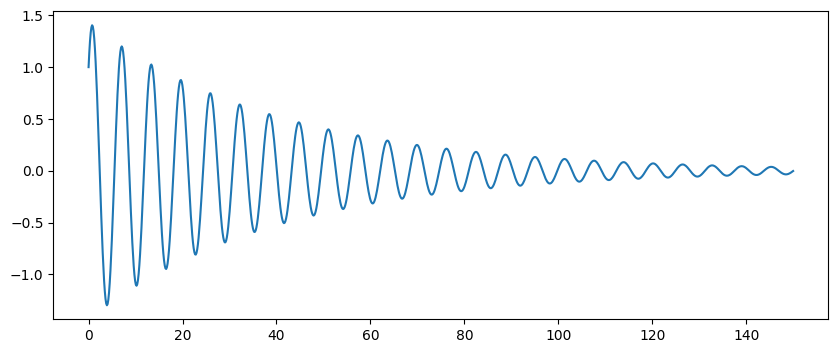

In [10]:
plt.figure(figsize = (10,4))
plt.plot(t,Uc)

In [ ]:
# 외력이 있는 경우의 응답 (강제진동)
# Ud = Uc(자유진동 응답) + Up (외력에의한 응답)


In [12]:
#강제 진동 입력
wf = 0.3 # 외력의 진동수
F0 = 1   # 외력의 진폭


In [21]:
# 강제 진동 응답
a = F0*(k-m*wf**2)/((k-m*wf**2)**2+(2*c*wf)**2)

b = -F0*2*c*wf/((k-m*wf**2)**2+(2*c*wf)**2)

In [22]:
Up = a*np.sin(wf*t)+b*np.cos(wf*t)

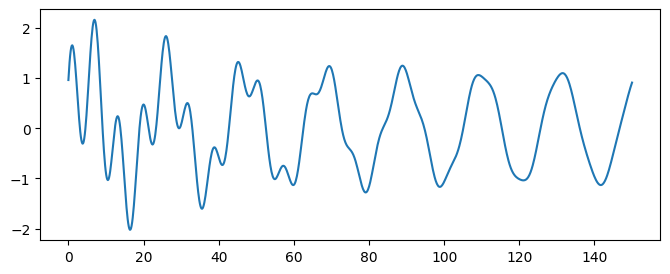

In [24]:
plt.figure(figsize=(8,3))
plt.plot(t,Uc+Up)
plt.show()

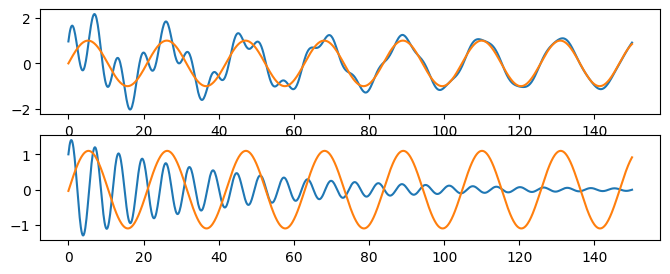

In [27]:
plt.figure(figsize=(8,3))
plt.subplot(2,1,1)
plt.plot(t,Uc+Up)   # 최종 응답
plt.plot(t,np.sin(wf*t))   # 외력 sin wf*t

plt.subplot(2,1,2)
plt.plot(t,Uc)   # 자유진동 응답
plt.plot(t,Up)   # 강제진동 응답